# Tarea 8: Redes Neuronales Convolucionales

Notebook preparado para Visual Studio Code.

Objetivos:
- Implementar una CNN propia y compararla con Transfer Learning.
- Experimentar con Data Augmentation y observar su impacto.
- Analizar ventajas de reutilizar MobileNetV2 pre-entrenada.

In [15]:
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import datasets, layers
from tensorflow.keras.models import Sequential

tf.random.set_seed(42)
np.random.seed(42)

(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_test:', X_test.shape, 'y_test:', y_test.shape)

X_train: (50000, 32, 32, 3) y_train: (50000, 1)
X_test: (10000, 32, 32, 3) y_test: (10000, 1)


## Parte 1 - Laboratorio de Datos e Invarianza

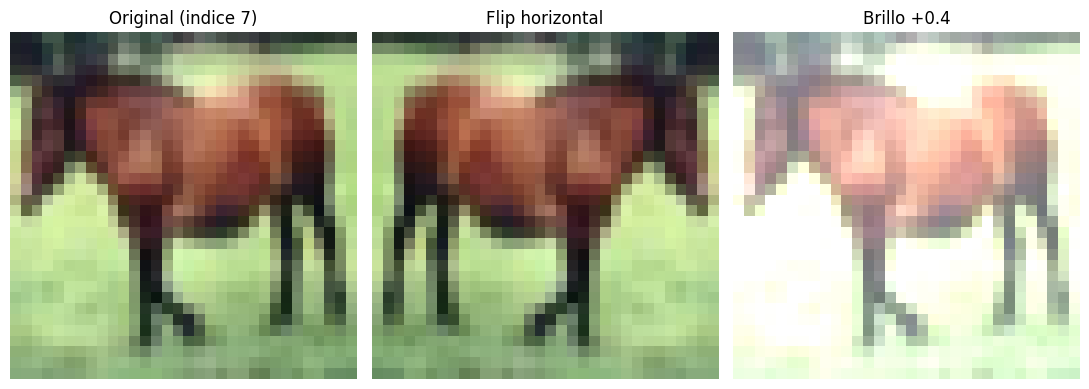

In [16]:
indice = 7
img = X_train[indice]

img_flip = tf.image.flip_left_right(img)
img_bright = tf.image.adjust_brightness(img, 0.4)

plt.figure(figsize=(11, 4))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title(f'Original (indice {indice})')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_flip)
plt.title('Flip horizontal')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(tf.clip_by_value(img_bright, 0.0, 1.0))
plt.title('Brillo +0.4')
plt.axis('off')

plt.tight_layout()
plt.show()

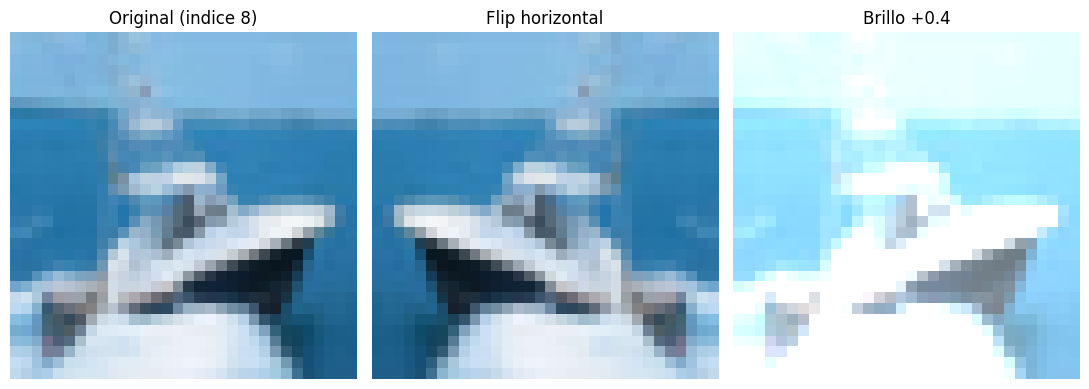

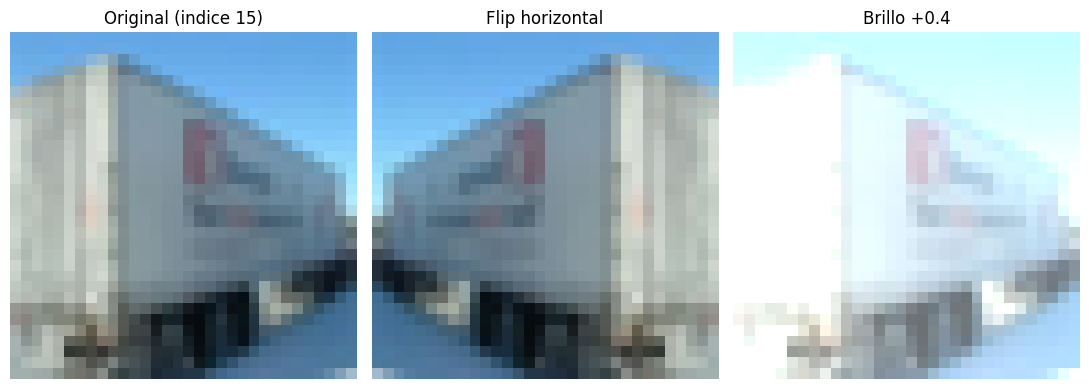

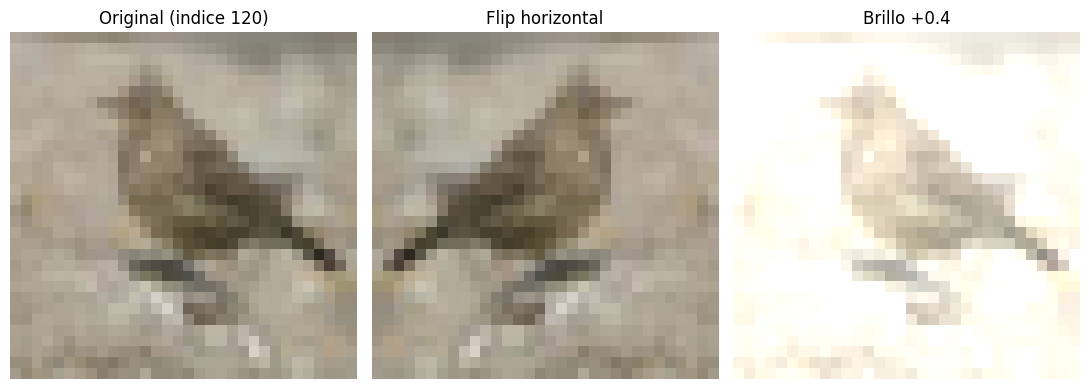

In [17]:
indices = [8, 15, 120]

for idx in indices:
    img = X_train[idx]
    img_flip = tf.image.flip_left_right(img)
    img_bright = tf.image.adjust_brightness(img, 0.4)

    plt.figure(figsize=(11, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title(f'Original (indice {idx})')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(img_flip)
    plt.title('Flip horizontal')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(tf.clip_by_value(img_bright, 0.0, 1.0))
    plt.title('Brillo +0.4')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

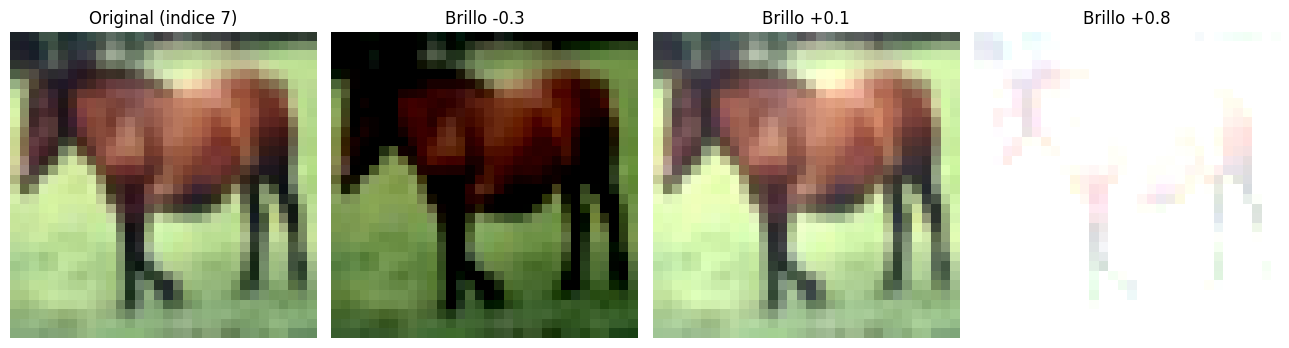

In [18]:
indice = 7
img = X_train[indice]
brillos = [-0.3, 0.1, 0.8]

plt.figure(figsize=(13, 4))
plt.subplot(1, 4, 1)
plt.imshow(img)
plt.title(f'Original (indice {indice})')
plt.axis('off')

for i, b in enumerate(brillos, start=2):
    img_b = tf.image.adjust_brightness(img, b)
    plt.subplot(1, 4, i)
    plt.imshow(tf.clip_by_value(img_b, 0.0, 1.0))
    plt.title(f'Brillo {b:+}')
    plt.axis('off')

plt.tight_layout()
plt.show()

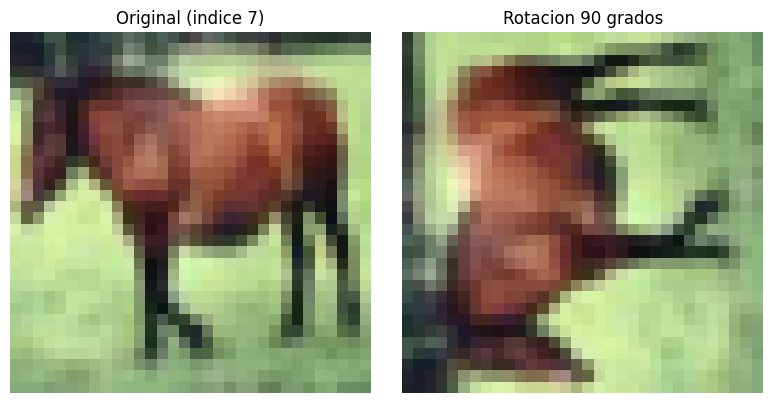

In [19]:
indice = 7
img = X_train[indice]
img_rot = tf.image.rot90(img)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title(f'Original (indice {indice})')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_rot)
plt.title('Rotacion 90 grados')
plt.axis('off')

plt.tight_layout()
plt.show()

## Parte 2 - CNN desde cero

In [20]:
def build_cnn(num_filters=32, use_pool=True):
    model = Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.Conv2D(num_filters, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)) if use_pool else layers.Activation('linear'),
        layers.Conv2D(num_filters * 2, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)) if use_pool else layers.Activation('linear'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_cnn = build_cnn(num_filters=32, use_pool=True)
model_cnn.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_5 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_5               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
inicio = time.time()
history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=2,
    batch_size=64,
    verbose=1
)
tiempo_cnn = time.time() - inicio

loss_cnn, acc_cnn = model_cnn.evaluate(X_test, y_test, verbose=0)
print(f'CNN base -> loss: {loss_cnn:.4f}, accuracy: {acc_cnn:.4f}, tiempo: {tiempo_cnn:.2f}s')

Epoch 1/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.4136 - loss: 1.6247
Epoch 2/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.5174 - loss: 1.3568
CNN base -> loss: 1.2250, accuracy: 0.5565, tiempo: 27.19s


In [22]:
filtros = [16, 64, 128]
resultados_filtros = []

for f in filtros:
    print(f'\nEntrenando modelo con {f} filtros iniciales...')
    model_tmp = build_cnn(num_filters=f, use_pool=True)
    t0 = time.time()
    model_tmp.fit(X_train, y_train, epochs=2, batch_size=64, verbose=1)
    elapsed = time.time() - t0
    loss, acc = model_tmp.evaluate(X_test, y_test, verbose=0)
    resultados_filtros.append((f, loss, acc, elapsed))

print('\nResultados (filtros, loss, accuracy, tiempo_s):')
for r in resultados_filtros:
    print(r)


Entrenando modelo con 16 filtros iniciales...
Epoch 1/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.4029 - loss: 1.6519
Epoch 2/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.4983 - loss: 1.4011

Entrenando modelo con 64 filtros iniciales...
Epoch 1/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.4206 - loss: 1.6025
Epoch 2/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 69ms/step - accuracy: 0.5364 - loss: 1.3074

Entrenando modelo con 128 filtros iniciales...
Epoch 1/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 120s 149ms/step - accuracy: 0.4291 - loss: 1.5777
Epoch 2/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 108s 139ms/step - accuracy: 0.5486 - loss: 1.2765

Resultados (filtros, loss, accuracy, tiempo_s):
(16, 1.297805905342102, 0.550599992275238, 19.07852339744568)
(64, 1.1616125106811523, 0.5873000025749207, 94.82817363739014)
(128, 1.1330136060714722, 0.5992000102996826, 228.94475317001343)


In [23]:
model_sin_pool = build_cnn(num_filters=32, use_pool=False)
model_sin_pool.summary()

t0 = time.time()
model_sin_pool.fit(X_train, y_train, epochs=2, batch_size=64, verbose=1)
tiempo_sin_pool = time.time() - t0

loss_sin_pool, acc_sin_pool = model_sin_pool.evaluate(X_test, y_test, verbose=0)
print(f'Sin pooling -> loss: {loss_sin_pool:.4f}, accuracy: {acc_sin_pool:.4f}, tiempo: {tiempo_sin_pool:.2f}s')
print(f'Con pooling -> loss: {loss_cnn:.4f}, accuracy: {acc_cnn:.4f}, tiempo: {tiempo_cnn:.2f}s')

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_9 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_9               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,231,370 (12.33 MB)

 Trainable params: 3,231,370 (12.33 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 55s 69ms/step - accuracy: 0.4348 - loss: 1.5780
Epoch 2/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 69ms/step - accuracy: 0.5404 - loss: 1.2989
Sin pooling -> loss: 1.1735, accuracy: 0.5837, tiempo: 109.10s
Con pooling -> loss: 1.2250, accuracy: 0.5565, tiempo: 27.19s


## Parte 3 - Transfer Learning con MobileNetV2

In [24]:
from pathlib import Path
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

X_train_tl = preprocess_input((X_train * 255.0).astype('float32'))
X_test_tl = preprocess_input((X_test * 255.0).astype('float32'))

keras_models_dir = Path.home() / '.keras' / 'models'
local_weights = keras_models_dir / 'mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5'
weights_arg = 'imagenet'
if local_weights.exists():
    weights_arg = str(local_weights)
    print(f'Usando pesos locales: {local_weights}')
else:
    print('No se encontraron pesos locales en cache. Se intentara descargar ImageNet.')

try:
    base_model = MobileNetV2(
        input_shape=(32, 32, 3),
        include_top=False,
        weights=weights_arg
    )
except Exception as e:
    print('No fue posible cargar pesos preentrenados (problema de red o DNS).')
    print(f'Detalle: {e}')
    print('Se crea MobileNetV2 sin preentrenamiento (weights=None) para continuar.')
    base_model = MobileNetV2(
        input_shape=(32, 32, 3),
        include_top=False,
        weights=None
    )

base_model.trainable = False

model_tl = Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(10, activation='softmax')
])

model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_tl.summary()

Usando pesos locales: C:\Users\tteru\.keras\models\mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_32             │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:
inicio = time.time()
history_tl = model_tl.fit(
    X_train_tl, y_train,
    epochs=5,
    batch_size=64,
    verbose=1
)
tiempo_tl = time.time() - inicio

loss_tl, acc_tl = model_tl.evaluate(X_test_tl, y_test, verbose=0)
print(f'Transfer Learning -> loss: {loss_tl:.4f}, accuracy: {acc_tl:.4f}, tiempo: {tiempo_tl:.2f}s')

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 49ms/step - accuracy: 0.2514 - loss: 2.1270
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.2795 - loss: 2.0134
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 49ms/step - accuracy: 0.2840 - loss: 1.9819
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.2864 - loss: 1.9668
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.2889 - loss: 1.9578
Transfer Learning -> loss: 1.9689, accuracy: 0.2834, tiempo: 188.63s


In [26]:
print(f'Accuracy CNN Propia: {acc_cnn:.4f} | Accuracy Transfer Learning: {acc_tl:.4f}')

Accuracy CNN Propia: 0.5565 | Accuracy Transfer Learning: 0.2834
